In [11]:
from konlpy.tag import *

import koreanize_matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
import os, platform

In [23]:
df = pd.read_csv('data/korean_youtube_food_comments.csv')
df

,start,end,category,answered,likes,review
0,2024-05-20,2024-05-21,한식,7,71,다음에는 홍대 다른 맛집도 소개해주세요!
1,2024-10-06,2024-10-06,한식,18,216,합정 가면 여기 꼭 가봐야겠네요! 떡볶이 진짜 맛있어 보입니다.
2,2024-04-21,2024-04-22,한식,16,308,강남 가면 여기 꼭 가봐야겠네요! 삼겹살 진짜 맛있어 보입니다.
3,2024-10-06,2024-10-09,중식,7,229,마라탕 좋아하는데 이런 맛집이 있었다니!
4,2024-01-04,2024-01-05,한식,13,174,와 칼국수 진짜 맛있어 보이네요. 침 고입니다.
...,...,...,...,...,...,...
995,2024-01-15,2024-01-16,동남아,6,169,오늘 저녁 메뉴는 쌀국수로 결정했습니다.
996,2024-09-02,2024-09-05,한식,1,330,보쌈 비주얼 미쳤네요… 다음 주말에 가볼게요!
997,2024-08-23,2024-08-25,양식,14,401,오늘 저녁 메뉴는 피자로 결정했습니다.
998,2024-01-29,2024-01-31,일식,18,371,영상 퀄리티도 좋고 정보도 좋아요.


In [24]:
df.describe

<bound method NDFrame.describe of           start         end category  answered  likes  \
0    2024-05-20  2024-05-21       한식         7     71   
1    2024-10-06  2024-10-06       한식        18    216   
2    2024-04-21  2024-04-22       한식        16    308   
3    2024-10-06  2024-10-09       중식         7    229   
4    2024-01-04  2024-01-05       한식        13    174   
..          ...         ...      ...       ...    ...   
995  2024-01-15  2024-01-16      동남아         6    169   
996  2024-09-02  2024-09-05       한식         1    330   
997  2024-08-23  2024-08-25       양식        14    401   
998  2024-01-29  2024-01-31       일식        18    371   
999  2024-10-01  2024-10-01       한식         6    295   

                                  review  
0                 다음에는 홍대 다른 맛집도 소개해주세요!  
1    합정 가면 여기 꼭 가봐야겠네요! 떡볶이 진짜 맛있어 보입니다.  
2    강남 가면 여기 꼭 가봐야겠네요! 삼겹살 진짜 맛있어 보입니다.  
3                 마라탕 좋아하는데 이런 맛집이 있었다니!  
4             와 칼국수 진짜 맛있어 보이네요. 침 고입니다.  
..                     

### likes 100 이상 데이터만 보기

In [28]:
likes_100 = df[df['likes'] >= 100]
likes_100

,start,end,category,answered,likes,review
1,2024-10-06,2024-10-06,한식,18,216,합정 가면 여기 꼭 가봐야겠네요! 떡볶이 진짜 맛있어 보입니다.
2,2024-04-21,2024-04-22,한식,16,308,강남 가면 여기 꼭 가봐야겠네요! 삼겹살 진짜 맛있어 보입니다.
3,2024-10-06,2024-10-09,중식,7,229,마라탕 좋아하는데 이런 맛집이 있었다니!
4,2024-01-04,2024-01-05,한식,13,174,와 칼국수 진짜 맛있어 보이네요. 침 고입니다.
5,2024-06-21,2024-06-21,한식,2,194,영상 보고 바로 저장했습니다. 순대국 먹으러 이태원 가야겠어요.
...,...,...,...,...,...,...
995,2024-01-15,2024-01-16,동남아,6,169,오늘 저녁 메뉴는 쌀국수로 결정했습니다.
996,2024-09-02,2024-09-05,한식,1,330,보쌈 비주얼 미쳤네요… 다음 주말에 가볼게요!
997,2024-08-23,2024-08-25,양식,14,401,오늘 저녁 메뉴는 피자로 결정했습니다.
998,2024-01-29,2024-01-31,일식,18,371,영상 퀄리티도 좋고 정보도 좋아요.


In [29]:
likes_100.shape

(807, 6)

### 어떤 카테고리가 likes를 많이 받았나

In [31]:
# 카테고리별 likes 평균 랭킹
category_like_rank = (df.groupby('category')['likes']
            .mean()
            .sort_values(ascending=False))
category_like_rank

category
일식     262.850340
한식     258.187037
남미     243.407407
중식     241.018182
양식     234.025157
동남아    228.066667
Name: likes, dtype: float64

In [34]:
# 카테고리별 likes 합계
category_like_sum = ( df.groupby('category')['likes']
                      .sum()
                      .sort_values(ascending=False))

category_like_sum

category
한식     139421
일식      38639
양식      37210
중식      13256
남미      13144
동남아     10263
Name: likes, dtype: int64

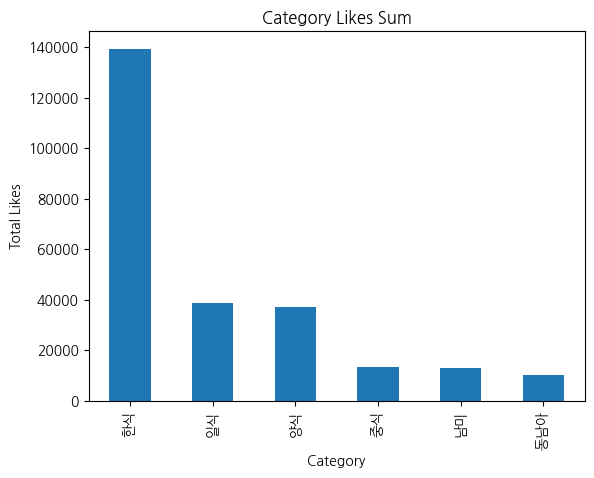

In [37]:
# 카테고리별 likes 시각화
category_like_sum.plot(kind='bar')

plt.title("Category Likes Sum")
plt.xlabel("Category")
plt.ylabel("Total Likes")
plt.show()

### 날짜별 likes 집계 (likes 많이 받은 날)

In [38]:
df['start'] = pd.to_datetime(df['start'])

In [44]:
likes_by_day = df.groupby('start')['likes'].sum().sort_values(ascending=False)

likes_by_day.head(10)

start
2024-01-28    2186
2024-10-07    2093
2024-07-14    2079
2024-10-25    2003
2024-04-25    1922
2024-01-19    1909
2024-10-19    1871
2024-07-10    1866
2024-06-24    1861
2024-06-08    1820
Name: likes, dtype: int64

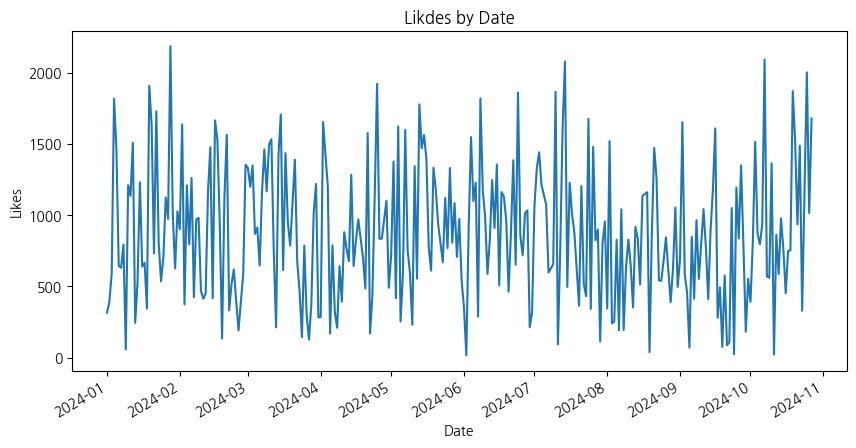

In [45]:
likes_daily = df.groupby('start')['likes'].sum()

likes_daily.plot(figsize=(10,5))

plt.title("Likdes by Date")
plt.xlabel("Date")
plt.ylabel("Likes")
plt.show()

### Likes EDA

In [46]:
df['likes'].describe()

count    1000.000000
mean      251.933000
std       144.072382
min         0.000000
25%       132.500000
50%       256.000000
75%       371.000000
max       500.000000
Name: likes, dtype: float64

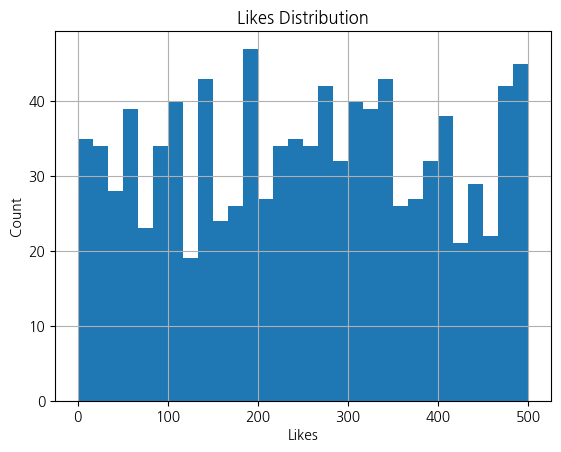

In [47]:
df['likes'].hist(bins=30)

plt.title("Likes Distribution")
plt.xlabel("Likes")
plt.ylabel("Count")
plt.show()

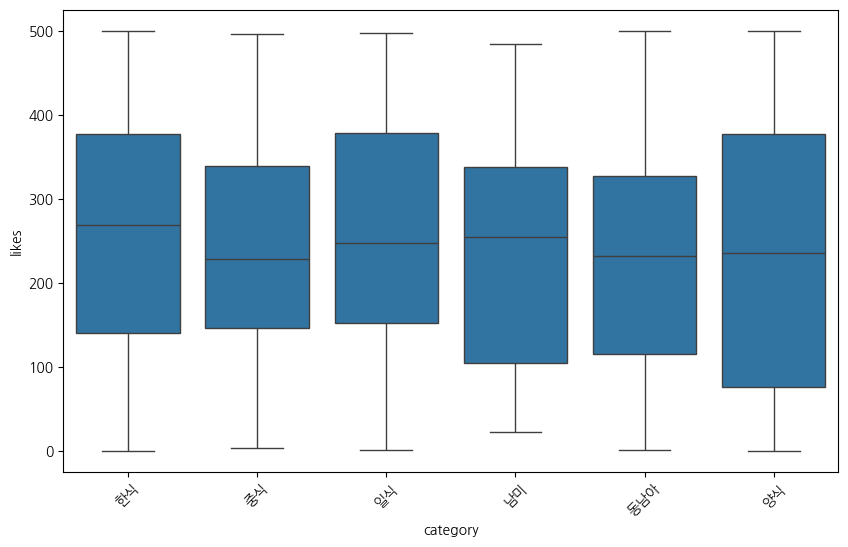

In [53]:
plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='likes', data=df)

plt.xticks(rotation=45)
plt.show()

### 관심 키워드 들어간 댓글 추출 

In [54]:
chicken_comments = df[df['review'].str.contains('치킨', na=False)]

chicken_comments.head()

,start,end,category,answered,likes,review
18,2024-01-25,2024-01-25,한식,4,321,치킨 비주얼 미쳤네요… 다음 주말에 가볼게요!
33,2024-01-31,2024-02-01,한식,2,463,압구정 가면 여기 꼭 가봐야겠네요! 치킨 진짜 맛있어 보입니다.
92,2024-03-18,2024-03-19,한식,12,355,치킨 비주얼 미쳤네요… 다음 주말에 가볼게요!
131,2024-01-28,2024-01-29,한식,4,415,치킨 좋아하는데 이런 맛집이 있었다니!
136,2024-05-02,2024-05-03,한식,17,38,치킨 비주얼 미쳤네요… 다음 주말에 가볼게요!


### 명사 기반 워드클라우드

In [58]:
from konlpy.tag import Okt

okt = Okt()
nouns = []

for text in df['review'].dropna():
    nouns.extend(okt.nouns(text))

In [59]:
nouns

['다음',
 '홍대',
 '다른',
 '맛집',
 '소개',
 '합정',
 '가면',
 '여기',
 '꼭',
 '떡볶이',
 '진짜',
 '강남',
 '가면',
 '여기',
 '꼭',
 '삼겹살',
 '진짜',
 '탕',
 '맛집',
 '칼국수',
 '진짜',
 '침',
 '고',
 '영상',
 '보고',
 '바로',
 '저장',
 '대국',
 '이태원',
 '가격',
 '용산',
 '때',
 '오늘',
 '저녁',
 '메뉴',
 '탕로',
 '결정',
 '영상',
 '퀄리티',
 '정보',
 '영상',
 '보고',
 '바로',
 '저장',
 '냉면',
 '여의도',
 '여기',
 '예전',
 '또',
 '초밥',
 '최고',
 '갈비',
 '비주',
 '얼',
 '다음',
 '주말',
 '탕',
 '진짜',
 '침',
 '고',
 '이태원',
 '가면',
 '여기',
 '꼭',
 '탕',
 '진짜',
 '보쌈',
 '맛집',
 '보쌈',
 '비주',
 '얼',
 '다음',
 '주말',
 '맛집',
 '소개',
 '가격',
 '잠실',
 '때',
 '치킨',
 '비주',
 '얼',
 '다음',
 '주말',
 '가격',
 '망원',
 '때',
 '맛집',
 '소개',
 '항상',
 '맛집',
 '채널',
 '곱창',
 '비주',
 '얼',
 '다음',
 '주말',
 '버거',
 '맛집',
 '여기',
 '줄',
 '서나',
 '영상',
 '보고',
 '바로',
 '저장',
 '버거',
 '촌',
 '맛집',
 '소개',
 '여기',
 '줄',
 '서나',
 '이',
 '채널',
 '때문',
 '다이어트',
 '포기',
 '이',
 '채널',
 '때문',
 '다이어트',
 '포기',
 '가격',
 '압구정',
 '때',
 '여기',
 '예전',
 '또',
 '버거',
 '최고',
 '망원',
 '가면',
 '여기',
 '꼭',
 '삼겹살',
 '진짜',
 '압구정',
 '가면',
 '여기',
 '꼭',
 '치킨',
 '진짜',
 '가격',
 '강남',
 '때',

In [60]:
stopwords = ['영상', '진짜', '너무', '정말', 'ㅋㅋ', 'ㅎㅎ', '오늘']

nouns = [word for word in nouns if word not in stopwords and len(word) > 1]

In [61]:
nouns

['다음',
 '홍대',
 '다른',
 '맛집',
 '소개',
 '합정',
 '가면',
 '여기',
 '떡볶이',
 '강남',
 '가면',
 '여기',
 '삼겹살',
 '맛집',
 '칼국수',
 '보고',
 '바로',
 '저장',
 '대국',
 '이태원',
 '가격',
 '용산',
 '저녁',
 '메뉴',
 '탕로',
 '결정',
 '퀄리티',
 '정보',
 '보고',
 '바로',
 '저장',
 '냉면',
 '여의도',
 '여기',
 '예전',
 '초밥',
 '최고',
 '갈비',
 '비주',
 '다음',
 '주말',
 '이태원',
 '가면',
 '여기',
 '보쌈',
 '맛집',
 '보쌈',
 '비주',
 '다음',
 '주말',
 '맛집',
 '소개',
 '가격',
 '잠실',
 '치킨',
 '비주',
 '다음',
 '주말',
 '가격',
 '망원',
 '맛집',
 '소개',
 '항상',
 '맛집',
 '채널',
 '곱창',
 '비주',
 '다음',
 '주말',
 '버거',
 '맛집',
 '여기',
 '서나',
 '보고',
 '바로',
 '저장',
 '버거',
 '맛집',
 '소개',
 '여기',
 '서나',
 '채널',
 '때문',
 '다이어트',
 '포기',
 '채널',
 '때문',
 '다이어트',
 '포기',
 '가격',
 '압구정',
 '여기',
 '예전',
 '버거',
 '최고',
 '망원',
 '가면',
 '여기',
 '삼겹살',
 '압구정',
 '가면',
 '여기',
 '치킨',
 '가격',
 '강남',
 '가격',
 '신촌',
 '항상',
 '맛집',
 '채널',
 '다음',
 '건대',
 '다른',
 '맛집',
 '소개',
 '채널',
 '때문',
 '다이어트',
 '포기',
 '성수',
 '맛집',
 '채널',
 '때문',
 '다이어트',
 '포기',
 '가격',
 '강남',
 '용산',
 '가면',
 '여기',
 '갈비',
 '다음',
 '종로',
 '다른',
 '맛집',
 '소개',
 '합정',
 '맛집',
 '망원',
 '가면',
 '

In [62]:
from collections import Counter

word_freq = Counter(nouns)
word_freq.most_common(20)

[('맛집', 330),
 ('여기', 188),
 ('다음', 155),
 ('채널', 145),
 ('소개', 128),
 ('퀄리티', 79),
 ('정보', 79),
 ('비주', 79),
 ('주말', 79),
 ('다른', 76),
 ('항상', 76),
 ('가격', 75),
 ('때문', 69),
 ('다이어트', 69),
 ('포기', 69),
 ('서나', 65),
 ('예전', 63),
 ('최고', 63),
 ('가면', 60),
 ('저녁', 59)]

In [64]:
# pip install wordcloud

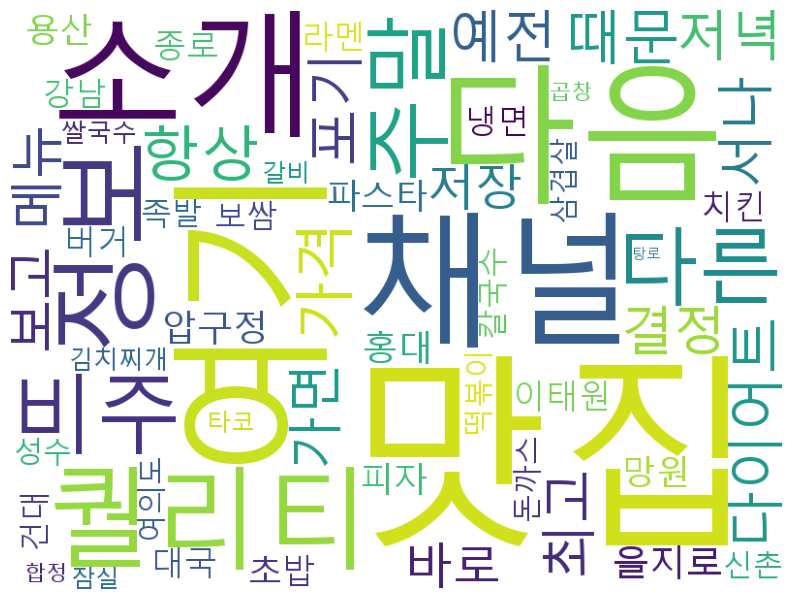

In [67]:
from wordcloud import WordCloud

wc = WordCloud(
    font_path='malgun.ttf',
    background_color='white',
    width=800,
    height=600)

wc.generate_from_frequencies(word_freq)
plt.figure(figsize=(10,8))
plt.imshow(wc)
plt.axis('off')
plt.show()